# Reuters News Topic Classification - Data Loading

This notebook handles the initial data loading and preprocessing for the Reuters news topic classification task. We'll be using the Reuters-21578 corpus, a classic dataset of Reuters newswire articles labeled with economic topics.

## Dataset Overview

The Reuters-21578 corpus is a collection of 10,788 Reuters newswire articles that have been labeled with economic topics. Key features:

* Open license - freely redistributable for research/commercial use
* Rich, domain-specific text - financial and commodities news
* Benchmark pedigree - allows comparison against decades of literature

## Setup and Imports

In [6]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

In [7]:
import logging
import warnings
import random
import os
from src.datasets.dataset import load_data, load_data_temporal

# Disable HuggingFace tokenizers parallelism to prevent "got forked" deadlock warnings
os.environ["TOKENIZERS_PARALLELISM"] = "false"

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(levelname)s | %(message)s')
SEED = 42
random.seed(SEED)

## Load Dataset

We'll load the top 10 topics for clarity in our classification task.

In [8]:
# Load dataset with top 10 topics
N_CLASSES = 10
X_train, y_train, X_test, y_test, label_names = load_data(N_CLASSES)
print(f'Train docs: {len(X_train):,},  Test docs: {len(X_test):,}')
print('Labels:', label_names)

Train docs: 6,337,  Test docs: 2,477
Labels: ['earn', 'acq', 'crude', 'interest', 'money-fx', 'trade', 'grain', 'corn', 'dlr', 'money-supply']


## Temporal Split

We can also load the data using a temporal split, where articles before 1996 are used for training and those after for testing. This better reflects real-world deployment scenarios.

In [9]:
# Load using temporal split
X_train, y_train, X_test, y_test, label_names = load_data_temporal(
    cutoff_year=1996,
    n_classes=N_CLASSES
)
print(f"Train docs: {len(X_train):,},  Test docs: {len(X_test):,}")

Train docs: 6,337,  Test docs: 2,477


## Data Exploration

Let's examine the distribution of classes and article lengths to understand our dataset better.

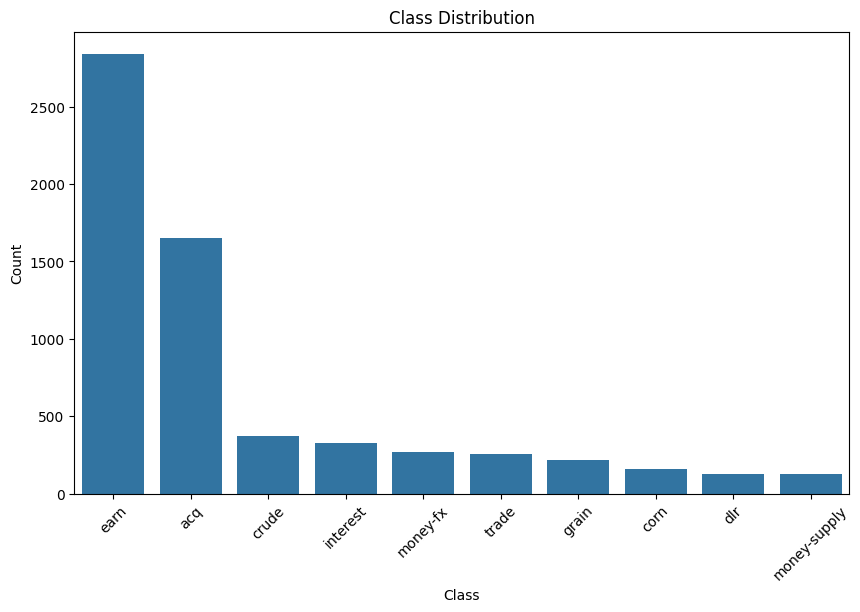

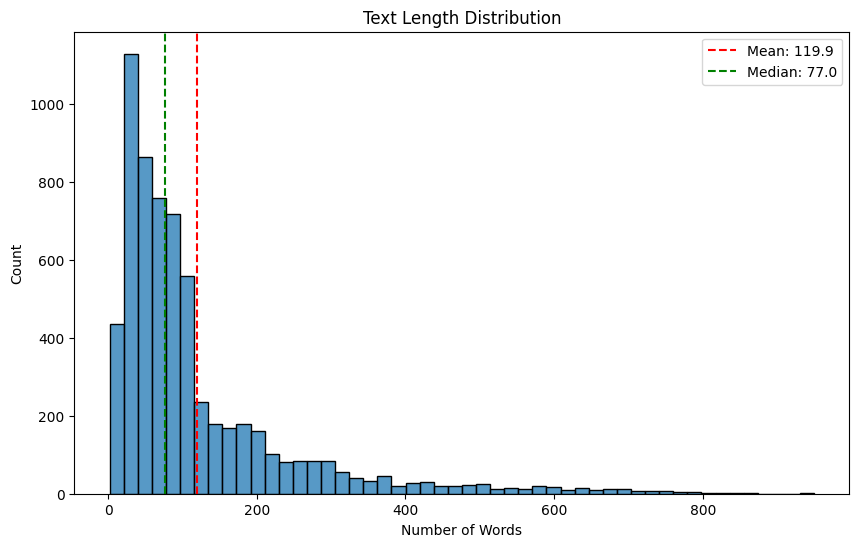

Mean length: 119.9 tokens, median: 77.0


In [10]:
from src.exploration import class_frequency, length_distribution
import pandas as pd


# Imbalance plot
class_frequency(y_train, top_n=20)

# Article length distribution
stats = length_distribution(X_train)
print(f"Mean length: {stats['stats']['mean']:.1f} tokens, median: {stats['stats']['median']}")

## Next Steps

The data has been loaded and preprocessed. In the next notebook, we'll perform more detailed exploratory data analysis to better understand the characteristics of our dataset.